In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import pickle as pkl

In [48]:
path = '/home/haitong/PycharmProjects/lvrep-rl-cloned/log/Pendulum-v1_sigma_1.0_rew_scale_0.2/rfsac_nystrom_False_rf_num_512_learn_rf_False'
noise_levels = [0.0, 1.0, 2.0, 3.0]
dfs = []
for exp in os.listdir(path):
    if not exp.startswith('skip'):
        exp_path = os.path.join(path, exp)
        df = pd.read_csv(os.path.join(exp_path, 'log.csv'))
        sliced_df = df.loc[df['avg_ret'].idxmax()]
        if exp.startswith('seed_0'):
            sliced_df['algo'] = 'SDEC (RF)'
        elif exp.startswith('seed_1'):
            sliced_df['algo'] = 'SDEC (Nystrom)'
        with open(os.path.join(exp_path, 'train_params.pkl'), 'rb') as f:        
            kwargs = pkl.load(f)
            alpha = kwargs['alpha_scale']
            sliced_df['alpha'] = alpha
        sliced_df['exp'] = exp
        dfs.append(sliced_df)
           
total_df = pd.concat(dfs, axis=1, ignore_index=True).T


/tmp/ipykernel_744950/777900092.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sliced_df['algo'] = 'SDEC (Nystrom)'
/tmp/ipykernel_744950/777900092.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sliced_df['algo'] = 'SDEC (Nystrom)'
/tmp/ipykernel_744950/777900092.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sliced_df['alpha'] = alpha
/tmp/ipykernel_744950/777900092.py:16: SettingWithCopyWarning: 
A value is trying t

In [49]:
total_df

,step,avg_ret,std_ret,algo,alpha,exp
0,65000.0,-232.650907,164.457534,SDEC (Nystrom),0.5,seed_1_2024-12-30-23-01-05
1,75000.0,-232.739586,168.688478,SDEC (Nystrom),0.75,seed_1_2024-12-31-12-27-19_0.75
2,50000.0,-239.510259,167.912792,SDEC (RF),0.0,seed_0_2024-12-30-23-17-08
3,60000.0,-238.177183,166.452439,SDEC (Nystrom),0.25,seed_1_2024-12-31-12-27-19_0.25
4,75000.0,-236.645983,173.817193,SDEC (RF),0.25,seed_0_2024-12-31-12-27-39_0.25
5,65000.0,-236.550888,172.306949,SDEC (Nystrom),0.0,seed_1_2024-12-31-00-31-23
6,75000.0,-231.362329,168.75478,SDEC (RF),0.75,seed_0_2024-12-31-12-27-39_0.75
7,50000.0,-237.331908,174.858391,SDEC (RF),0.5,seed_0_2024-12-30-23-07-26


<class 'pandas.core.series.Series'> float64
<class 'pandas.core.series.Series'> 2   -71.597467
4   -62.828790
6   -62.607548
7   -62.473517
dtype: float64
<class 'pandas.core.series.Series'> float64
<class 'pandas.core.series.Series'> 0   -68.193374
1   -64.051108
3   -71.724743
5   -64.243940
dtype: float64


/tmp/ipykernel_744950/3490683239.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontname="Times New Roman")


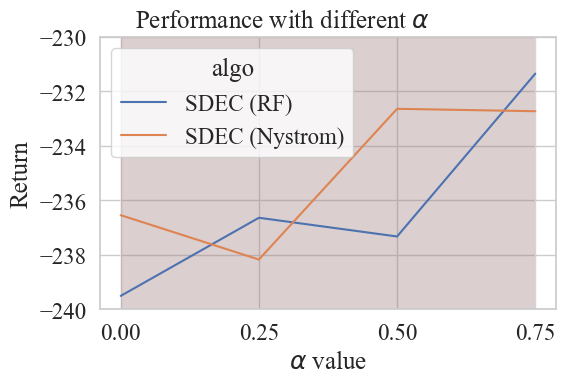

In [64]:
# sns.set_style('white')
sns.set(font_scale=1.5, style='whitegrid')
fig, ax = plt.subplots(figsize=(6, 4))
plt.rcParams['font.family'] = 'Times New Roman'
hue_order = ['SDEC (RF)', 'SDEC (Nystrom)']
# ax = sns.barplot(x='noise', y='avg_ret', hue='algo', data=total_df, hue_order=hue_order)
# 

sns.lineplot(x='alpha', y='avg_ret', hue='algo', data=total_df, hue_order=hue_order, ax=ax)
# total_df = total_df.map(lambda x: 'Algorithm' if x == 'algo' else x)
for i, alg in enumerate(hue_order):
    avg = total_df[total_df['algo'] == alg]['avg_ret'].astype(float)
    std = total_df[total_df['algo'] == alg]['std_ret'].astype(float)
    print(type(avg-std), (avg - std).dtype)
    print(type(avg + std), avg + std)
    ax.fill_between(np.array([0.0, 0.25, 0.5, 0.75]), avg-std, avg + std, alpha=0.2)
ax.set_ylabel('Return', fontname="Times New Roman")
ax.set_xlabel(r'$\alpha$ value', fontname="Times New Roman")
ax.set_xticks([0.0, 0.25, 0.5, 0.75])
ax.set_ylim([-240, -230])
ax.set_xticklabels(ax.get_xticklabels(), fontname="Times New Roman")
ax.set_yticklabels(ax.get_yticklabels(), fontname="Times New Roman")
plt.tight_layout()
h, l = ax.get_legend_handles_labels()
plt.suptitle(r'Performance with different $\alpha$', fontsize=18)

fig.savefig('/home/haitong/PycharmProjects/lvrep-rl-cloned/utils/alpha_eval.pdf')